# The Perfusion Continuum
## Continuous CO/CI Dynamics and their Laboratory Context

> *"A lactate of 4 tells you where the patient has been. A CO of 2.8 L/min tells you where they are going."*

### The Clinical Problem
We manage perfusion with two fundamentally different measurement systems:
- **Continuous monitors** — CO, CI, SVV, ETCO2: updated every heartbeat
- **Episodic labs** — pH, HCO3, lactate, PCO2, HCT: a snapshot every few hours

These systems describe the **same physiological truth** (oxygen delivery and tissue utilisation) but through different windows and time scales. When they disagree, we have a clinical problem.

### Physiological Framework
| Relationship | Formula | Clinical meaning |
|---|---|---|
| Oxygen delivery | DO₂ = CO × (Hb × 1.34 × SaO₂ + 0.003 × PaO₂) | CO × haemoglobin defines tissue O₂ supply |
| ETCO₂ ↓ = CO ↓ | VċO₂ = CO × (CvCO₂ − CaCO₂) | Less cardiac output → less CO₂ to lungs → ETCO₂ falls |
| HCO₃ / BE proxy for lactate | Metabolic acidosis = consumed bicarbonate = accumulated acid | Labs lag by hours; the monitor sees it first |
| SVV > 12% → preload responsive | PPV/SVV generated by heart-lung interaction | High SVV predicts CO response to fluid |

### Data
- **EV1000/CO, CI, SVV** — 617 cases at ~2-s resolution (fetched live from VitalDB API)
- **Solar8000/ETCO2** — 6,242 cases, continuous CO2 surrogate
- **Preop ABGs** (pH, HCO3, BE, PaCO2, PaO2, Hb) — static per-case, `all_cases.csv`
- **Cross-sectional cohort**: ~61 cases with both EV1000 and preop ABG

In [1]:
# ── Cell 1: Setup & imports ───────────────────────────────────────────────────
import warnings, io, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import requests
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, linregress
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

TEAL   = '#1A7F8E'; CRIMSON = '#C0392B'; AMBER = '#E67E22'
SLATE  = '#2C3E50'; GREEN   = '#27AE60'; PURPLE= '#8E44AD'
API    = 'https://api.vitaldb.net'

FIG_DIR  = Path('/Volumes/iDrisAI/VitalDBGit/co_figures')
CO_CACHE = Path('/Volumes/iDrisAI/VitalDBGit/co_cache')
FIG_DIR.mkdir(exist_ok=True)
CO_CACHE.mkdir(exist_ok=True)

BASE   = Path('/Volumes/iDrisAI/VitalDBGit')
tracks = pd.read_csv(BASE / 'vital_db' / 'tracks.csv')
cases  = pd.read_csv(BASE / 'vital_db' / 'all_cases.csv')

# ── Lab columns ───────────────────────────────────────────────────────────────
LAB_COLS = [c for c in ['preop_ph','preop_hco3','preop_be','preop_paco2',
                          'preop_pao2','preop_hb','preop_na','preop_k'] if c in cases.columns]
print(f'Lab columns available: {LAB_COLS}')

# HCT estimated from Hb (×3 rule, or ×0.295 for %)
if 'preop_hb' in cases.columns:
    cases['preop_hct'] = cases['preop_hb'] * 3   # approximate % HCT

# ── Track index by device ─────────────────────────────────────────────────────
def get_tids(tname):
    return tracks[tracks['tname'] == tname][['caseid','tid']].reset_index(drop=True)

ev_co  = get_tids('EV1000/CO')
ev_ci  = get_tids('EV1000/CI')
ev_svv = get_tids('EV1000/SVV')
ev_sv  = get_tids('EV1000/SV')
etco2  = get_tids('Solar8000/ETCO2')
sol_mbp= get_tids('Solar8000/ART_MBP')

print(f'\nDevice coverage:')
print(f'  EV1000/CO : {len(ev_co)} cases')
print(f'  EV1000/CI : {len(ev_ci)} cases')
print(f'  EV1000/SVV: {len(ev_svv)} cases')
print(f'  Solar8000/ETCO2: {len(etco2)} cases')

# ── Cross-sectional cohort (EV1000 + preop pH) ────────────────────────────────
ev_case_ids = ev_co['caseid'].unique()
xsect = cases[cases['caseid'].isin(ev_case_ids)].dropna(subset=['preop_ph'])
print(f'\nCross-sectional cohort (EV1000 + preop pH): {len(xsect)} cases')
print(f'Preop labs summary:')
print(xsect[LAB_COLS].describe().round(2).to_string())

def save_fig(name, fig=None, dpi=150):
    p = FIG_DIR / f'{name}.png'
    (fig or plt).savefig(p, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p.name}')

Lab columns available: ['preop_ph', 'preop_hco3', 'preop_be', 'preop_paco2', 'preop_pao2', 'preop_hb', 'preop_na', 'preop_k']

Device coverage:
  EV1000/CO : 617 cases
  EV1000/CI : 617 cases
  EV1000/SVV: 617 cases
  Solar8000/ETCO2: 6242 cases

Cross-sectional cohort (EV1000 + preop pH): 61 cases
Preop labs summary:
       preop_ph  preop_hco3  preop_be  preop_paco2  preop_pao2  preop_hb  preop_na  preop_k
count     61.00       56.00     56.00        61.00       61.00     61.00     59.00    59.00
mean       7.39       23.85     -0.52        40.10       95.27     12.17    139.14     4.25
std        0.06        3.13      3.53         7.62       39.76      2.55      3.51     0.72
min        7.15       15.70    -10.80        23.50       17.20      5.90    126.00     3.30
25%        7.37       22.85     -1.62        36.80       73.30     10.30    137.00     4.00
50%        7.40       24.15     -0.15        39.70       92.40     12.40    140.00     4.20
75%        7.43       26.20      2.0

In [2]:
# ── Cell 2: Fetch & cache EV1000 multi-signal data ───────────────────────────
N_FETCH = 8   # 8 cases × 4 signals = 32 API calls, well within timeout

def fetch_track(tid, label='value', timeout=20):
    cache_p = CO_CACHE / f'{tid}.parquet'
    if cache_p.exists():
        return pd.read_parquet(cache_p)
    try:
        r = requests.get(f'{API}/{tid}', timeout=timeout)
        if r.status_code == 200 and len(r.content) > 50:
            df = pd.read_csv(io.StringIO(r.text))
            df.columns = ['time_s', label]
            df = df.dropna()
            df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
            df[label]    = pd.to_numeric(df[label], errors='coerce')
            df = df.dropna()
            if len(df) > 5:
                df.to_parquet(cache_p, index=False)
                return df
    except Exception:
        pass
    return None

# Find cases with all EV1000 signals
multi_cids = set(ev_co['caseid']) & set(ev_ci['caseid']) & set(ev_svv['caseid'])
with_etco2 = set(etco2['caseid'])
priority   = sorted(multi_cids & with_etco2)[:N_FETCH]
if len(priority) < N_FETCH:
    priority += sorted(multi_cids - with_etco2)[:N_FETCH-len(priority)]
priority = priority[:N_FETCH]

print(f'Fetching {len(priority)} cases with EV1000 CO+CI+SVV...')
fetched = {}

for cid in priority:
    entry = {'caseid': cid}
    for signal, src_df, label in [
        ('co',  ev_co,  'co'),
        ('ci',  ev_ci,  'ci'),
        ('svv', ev_svv, 'svv'),
    ]:
        row = src_df[src_df['caseid']==cid]
        if len(row):
            df = fetch_track(row.iloc[0]['tid'], label=label)
            if df is not None and len(df) > 10:
                entry[signal] = df
    row_e = etco2[etco2['caseid']==cid]
    if len(row_e):
        df_e = fetch_track(row_e.iloc[0]['tid'], label='etco2')
        if df_e is not None and len(df_e) > 10:
            entry['etco2'] = df_e
    if 'co' in entry and 'ci' in entry:
        fetched[cid] = entry
        print(f'  Case {cid}: CO✓ CI✓ SVV={"✓" if "svv" in entry else "✗"} ETCO2={"✓" if "etco2" in entry else "✗"}')

print(f'\nFetched {len(fetched)} complete cases')

case_summary = []
for cid, entry in fetched.items():
    co_df  = entry.get('co')
    ci_df  = entry.get('ci')
    svv_df = entry.get('svv')
    e_df   = entry.get('etco2')
    row = {'caseid': cid}
    if co_df is not None:
        co_v = co_df['co'][(co_df['co'] > 1) & (co_df['co'] < 15)]
        row.update({'co_mean': co_v.mean(), 'co_min': co_v.min(),
                    'co_max': co_v.max(), 'co_std': co_v.std()})
    if ci_df is not None:
        ci_v = ci_df['ci'][(ci_df['ci'] > 0.5) & (ci_df['ci'] < 8)]
        row.update({'ci_mean': ci_v.mean(), 'ci_min': ci_v.min()})
    if svv_df is not None:
        svv_v = svv_df['svv'][(svv_df['svv'] >= 0) & (svv_df['svv'] <= 60)]
        row.update({'svv_mean': svv_v.mean(), 'svv_p75': np.percentile(svv_v, 75)})
    if e_df is not None:
        etco2_v = e_df['etco2'][(e_df['etco2'] > 15) & (e_df['etco2'] < 60)]
        row.update({'etco2_mean': etco2_v.mean(), 'etco2_min': etco2_v.min()})
    if len(row) > 1:
        case_summary.append(row)

cs = pd.DataFrame(case_summary)
cs = cs.merge(cases[['caseid'] + LAB_COLS + ['preop_hct']], on='caseid', how='left')
print(f'\nCase summary: {cs.shape}')
hd_cols = [c for c in ['co_mean','ci_mean','svv_mean','etco2_mean'] if c in cs.columns]
print(cs[hd_cols].describe().round(2).to_string())

Fetching 8 cases with EV1000 CO+CI+SVV...
  Case 17: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 19: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 25: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 29: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 34: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 52: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 55: CO✓ CI✓ SVV=✓ ETCO2=✓
  Case 60: CO✓ CI✓ SVV=✓ ETCO2=✓

Fetched 8 complete cases

Case summary: (8, 20)
       co_mean  ci_mean  svv_mean  etco2_mean
count     8.00     8.00      8.00        8.00
mean      5.45     3.18      8.14       34.57
std       1.81     0.90      2.65        2.78
min       3.05     1.85      5.08       27.94
25%       4.47     2.81      7.08       35.01
50%       5.25     3.09      7.90       35.60
75%       6.33     3.63      8.41       35.90
max       8.16     4.43     13.53       36.24


Deep-dive case: 17  |  Available signals: ['co', 'ci', 'svv', 'etco2']
  Saved: 01_perfusion_dashboard.png


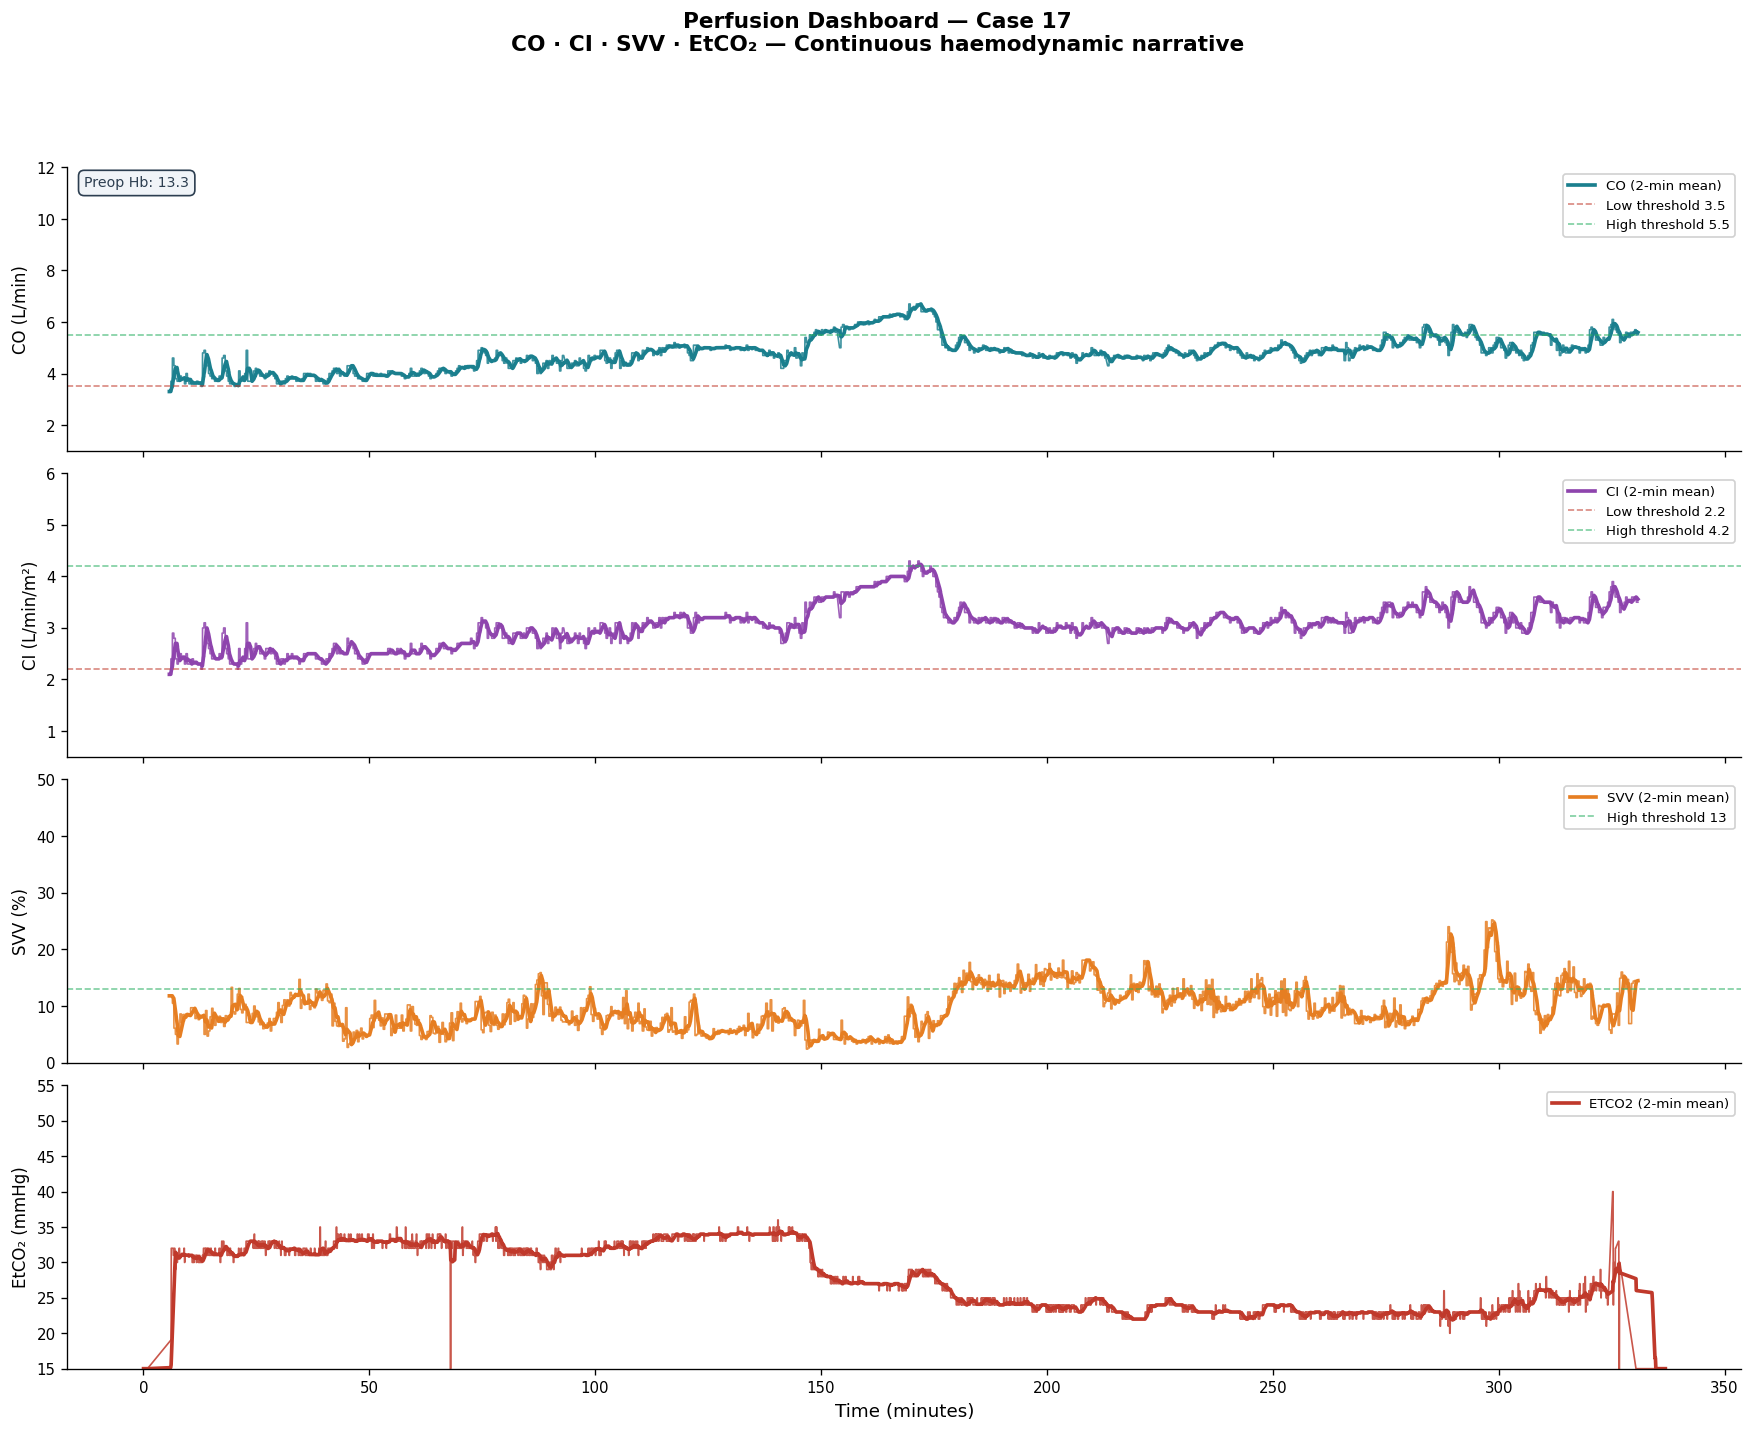

In [3]:
# ── Cell 3: Single case deep-dive — the full perfusion dashboard ──────────────
# Choose the case with the richest signal set (CO + CI + SVV + ETCO2)
rich = {cid: sum(k in v for k in ['co','ci','svv','etco2'])
        for cid, v in fetched.items()}
demo_cid = max(rich, key=rich.get)
entry    = fetched[demo_cid]
demo_info = cases[cases['caseid']==demo_cid].iloc[0] if len(cases[cases['caseid']==demo_cid]) > 0 else None

print(f'Deep-dive case: {demo_cid}  |  Available signals: {[k for k in entry if k != "caseid"]}')
if demo_info is not None and 'preop_ph' in demo_info and pd.notna(demo_info.get('preop_ph')):
    print(f'Preop ABG: pH={demo_info.get("preop_ph","?"):.2f}, '
          f'HCO3={demo_info.get("preop_hco3","?"):.1f}, '
          f'BE={demo_info.get("preop_be","?"):.1f}, '
          f'PaCO2={demo_info.get("preop_paco2","?"):.0f}, '
          f'Hb={demo_info.get("preop_hb","?"):.1f}')

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.08)
fig.patch.set_facecolor('white')
axes, share_ax = [], None

signal_cfg = [
    ('co',    'Cardiac Output (L/min)',  TEAL,   (1, 12),  3.5,  5.5, 'CO (L/min)'),
    ('ci',    'Cardiac Index (L/min/m²)',PURPLE, (0.5, 6), 2.2,  4.2, 'CI (L/min/m²)'),
    ('svv',   'Stroke Volume Variation (%)', AMBER, (0, 50), None, 13, 'SVV (%)'),
    ('etco2', 'EtCO₂ (mmHg) — CO₂ delivery proxy', CRIMSON, (15, 55), None, None, 'EtCO₂ (mmHg)'),
]

for i, (sig, title, col, ylim, lo, hi, ylabel) in enumerate(signal_cfg):
    df_s = entry.get(sig)
    if df_s is None:
        continue
    ax = fig.add_subplot(gs[i], sharex=share_ax)
    if share_ax is None: share_ax = ax
    t_m = df_s['time_s'] / 60
    v   = df_s[sig]
    # Clip to physiological range
    v   = v.clip(ylim[0], ylim[1])
    ax.plot(t_m, v, lw=1.0, color=col, alpha=0.85)
    # Rolling mean (2-min window)
    win = max(1, int(60 / (np.median(np.diff(df_s['time_s'])) if len(df_s) > 2 else 2)))
    ax.plot(t_m, v.rolling(win, min_periods=1).mean(), lw=2.2, color=col, label=f'{sig.upper()} (2-min mean)')
    if lo is not None:
        ax.axhline(lo, color=CRIMSON, ls='--', lw=1, alpha=0.6, label=f'Low threshold {lo}')
    if hi is not None:
        ax.axhline(hi, color=GREEN, ls='--', lw=1, alpha=0.6, label=f'High threshold {hi}')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(*ylim)
    if i < 3: plt.setp(ax.get_xticklabels(), visible=False)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    axes.append(ax)

if axes:
    axes[-1].set_xlabel('Time (minutes)', fontsize=11)

# Annotate preop lab context on the first axis
if axes and demo_info is not None:
    lab_txt = []
    for col_n, lbl in [('preop_ph','pH'),('preop_hco3','HCO₃'),
                         ('preop_be','BE'),('preop_hb','Hb')]:
        v = demo_info.get(col_n)
        if pd.notna(v): lab_txt.append(f'Preop {lbl}: {v:.1f}')
    if lab_txt:
        axes[0].text(0.01, 0.97, '\n'.join(lab_txt), transform=axes[0].transAxes,
                     fontsize=8.5, va='top', color=SLATE,
                     bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F4F8', edgecolor=SLATE))

plt.suptitle(f'Perfusion Dashboard — Case {demo_cid}\n'
             'CO · CI · SVV · EtCO₂ — Continuous haemodynamic narrative',
             fontsize=13, fontweight='bold')
save_fig('01_perfusion_dashboard')
plt.show()

  Saved: 02_co_ci_population.png


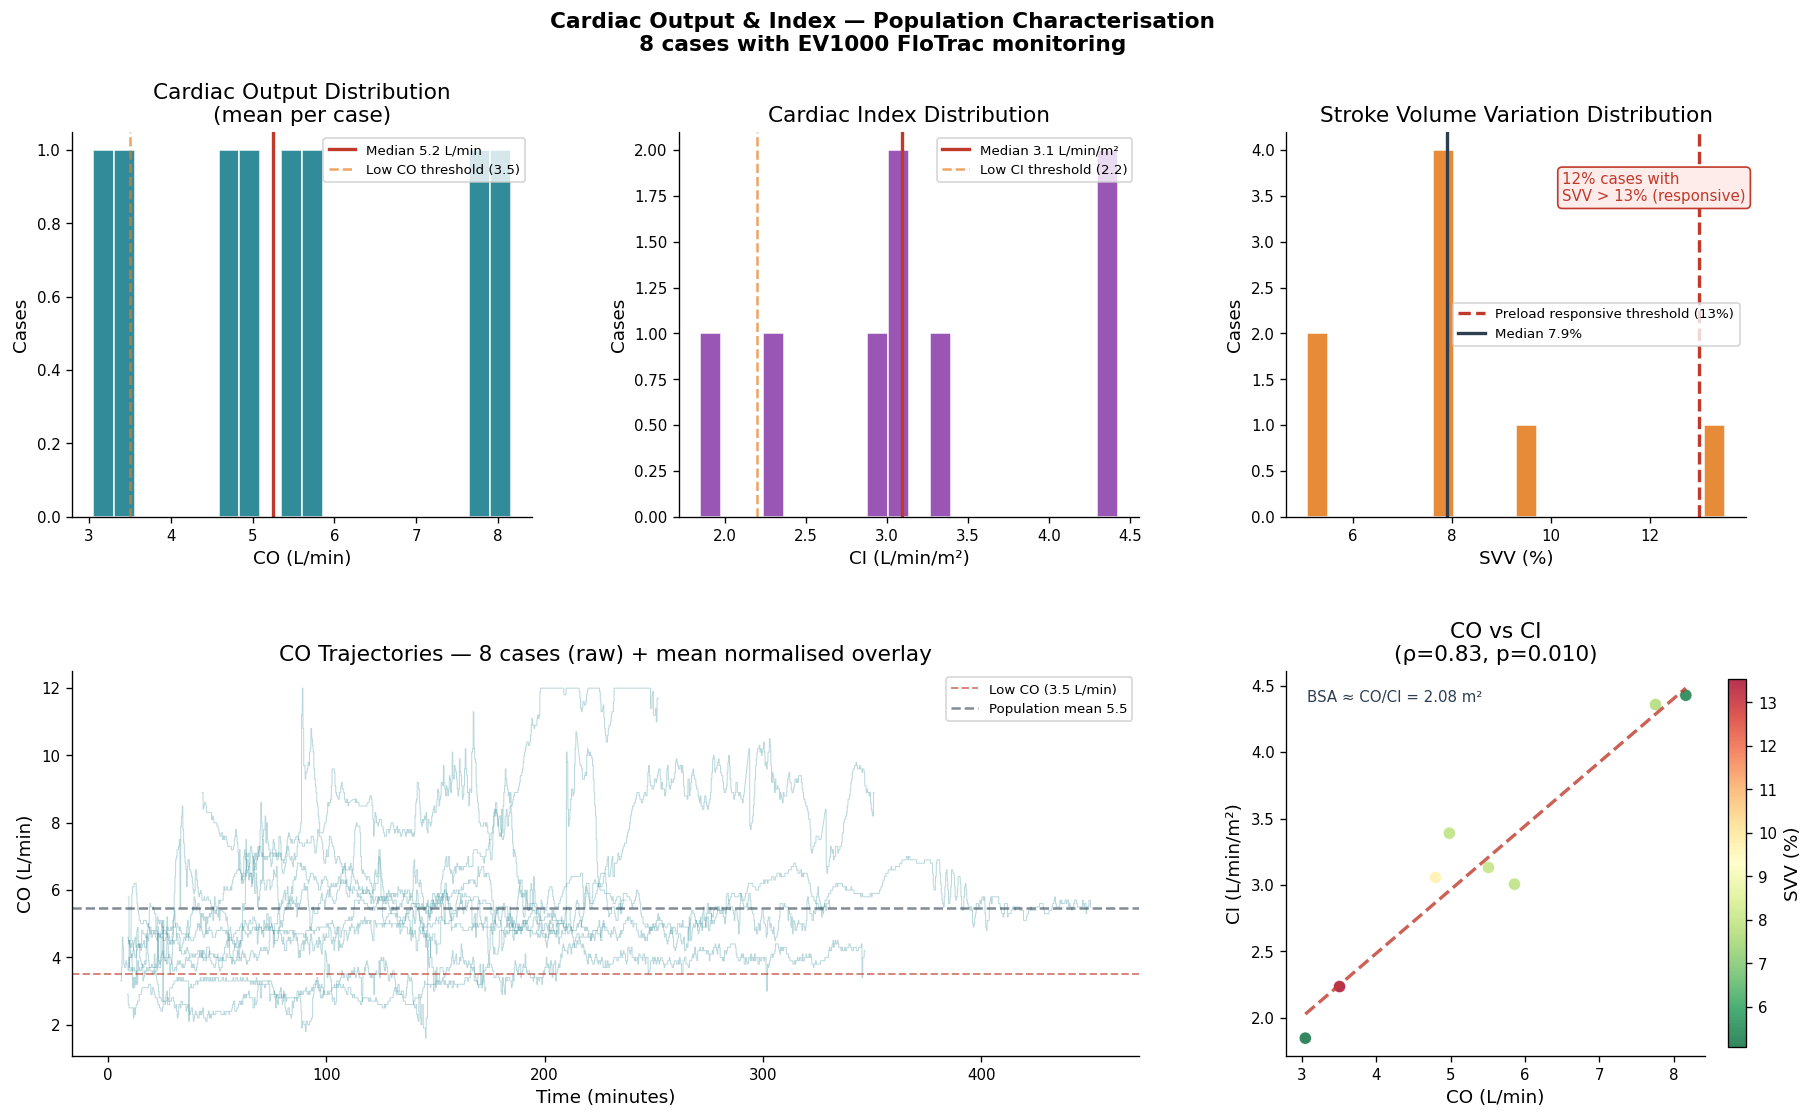

In [4]:
# ── Cell 4: CO/CI population characterisation ────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.32)
fig.patch.set_facecolor('white')

# ── 1: CO distribution ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
co_vals = cs['co_mean'].dropna()
ax1.hist(co_vals, bins=20, color=TEAL, edgecolor='white', alpha=0.9)
ax1.axvline(co_vals.median(), color=CRIMSON, lw=2, label=f'Median {co_vals.median():.1f} L/min')
ax1.axvline(3.5, color=AMBER, ls='--', lw=1.5, alpha=0.7, label='Low CO threshold (3.5)')
ax1.set(title='Cardiac Output Distribution\n(mean per case)', xlabel='CO (L/min)', ylabel='Cases')
ax1.legend(fontsize=8)

# ── 2: CI distribution ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ci_vals = cs['ci_mean'].dropna()
ax2.hist(ci_vals, bins=20, color=PURPLE, edgecolor='white', alpha=0.9)
ax2.axvline(ci_vals.median(), color=CRIMSON, lw=2, label=f'Median {ci_vals.median():.1f} L/min/m²')
ax2.axvline(2.2, color=AMBER, ls='--', lw=1.5, alpha=0.7, label='Low CI threshold (2.2)')
ax2.set(title='Cardiac Index Distribution', xlabel='CI (L/min/m²)', ylabel='Cases')
ax2.legend(fontsize=8)

# ── 3: SVV distribution ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if 'svv_mean' in cs.columns:
    svv_vals = cs['svv_mean'].dropna()
    ax3.hist(svv_vals, bins=20, color=AMBER, edgecolor='white', alpha=0.9)
    ax3.axvline(13, color=CRIMSON, ls='--', lw=2, label='Preload responsive threshold (13%)')
    ax3.axvline(svv_vals.median(), color=SLATE, lw=2, label=f'Median {svv_vals.median():.1f}%')
    pct_resp = 100 * np.mean(svv_vals > 13)
    ax3.text(0.6, 0.82, f'{pct_resp:.0f}% cases with\nSVV > 13% (responsive)',
             transform=ax3.transAxes, fontsize=9, color=CRIMSON,
             bbox=dict(boxstyle='round', facecolor='#FDECEA', edgecolor=CRIMSON))
    ax3.set(title='Stroke Volume Variation Distribution', xlabel='SVV (%)', ylabel='Cases')
    ax3.legend(fontsize=8)

# ── 4: CO over time (spaghetti) ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
for cid, entry in list(fetched.items())[:20]:
    if 'co' not in entry: continue
    df_c = entry['co']
    t_m  = df_c['time_s'] / 60
    co_v = df_c['co'].clip(1, 12)
    ax4.plot(t_m, co_v, lw=0.6, alpha=0.3, color=TEAL)
# Population mean (100-point normalised trajectory)
from scipy.interpolate import interp1d as interp1d_
co_trajs = []
for cid, entry in fetched.items():
    if 'co' not in entry: continue
    df_c = entry['co'].dropna()
    t_pct = 100 * (df_c['time_s'] - df_c['time_s'].min()) / (df_c['time_s'].max() - df_c['time_s'].min() + 1)
    co_v  = df_c['co'].clip(1, 12)
    f = interp1d_(t_pct, co_v, kind='linear', bounds_error=False, fill_value='extrapolate')
    co_trajs.append(f(np.linspace(0, 100, 100)))
if co_trajs:
    co_arr = np.array(co_trajs)
    ax4.set(xlabel='Time (minutes)', ylabel='CO (L/min)',
            title=f'CO Trajectories — {len(fetched)} cases (raw) + mean normalised overlay')
ax4.axhline(3.5, color=CRIMSON, ls='--', lw=1.2, alpha=0.6, label='Low CO (3.5 L/min)')
ax4.axhline(co_vals.mean(), color=SLATE, ls='--', lw=1.5, alpha=0.6, label=f'Population mean {co_vals.mean():.1f}')
ax4.legend(fontsize=8)

# ── 5: CO vs CI (sanity / BSA scatter) ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
common = cs.dropna(subset=['co_mean','ci_mean'])
sc = ax5.scatter(common['co_mean'], common['ci_mean'],
                  c=common.get('svv_mean', pd.Series([TEAL]*len(common))),
                  cmap='RdYlGn_r', s=55, alpha=0.8, edgecolors='white', lw=0.5)
if 'svv_mean' in common.columns:
    plt.colorbar(sc, ax=ax5, fraction=0.04, label='SVV (%)')
r, p = spearmanr(common['co_mean'], common['ci_mean'])
ax5.set(title=f'CO vs CI\n(ρ={r:.2f}, p={p:.3f})', xlabel='CO (L/min)', ylabel='CI (L/min/m²)')
m, b = np.polyfit(common['co_mean'], common['ci_mean'], 1)
x_line = np.linspace(common['co_mean'].min(), common['co_mean'].max(), 50)
ax5.plot(x_line, m*x_line+b, color=CRIMSON, lw=2, ls='--', alpha=0.8)
ax5.text(0.05, 0.92, f'BSA ≈ CO/CI = {1/m:.2f} m²', transform=ax5.transAxes, fontsize=9, color=SLATE)

plt.suptitle('Cardiac Output & Index — Population Characterisation\n'
             f'{len(fetched)} cases with EV1000 FloTrac monitoring',
             fontsize=13, fontweight='bold')
save_fig('02_co_ci_population')
plt.show()

Extending to up to 5 additional cross-sectional cases...
  +111: CO=6.1
  +157: CO=3.8
  +164: CO=9.5
  +321: CO=5.6
  +369: CO=5.9

Cross-sectional cohort with CO+labs: 6
  Saved: 03_lab_vs_co_scatter.png


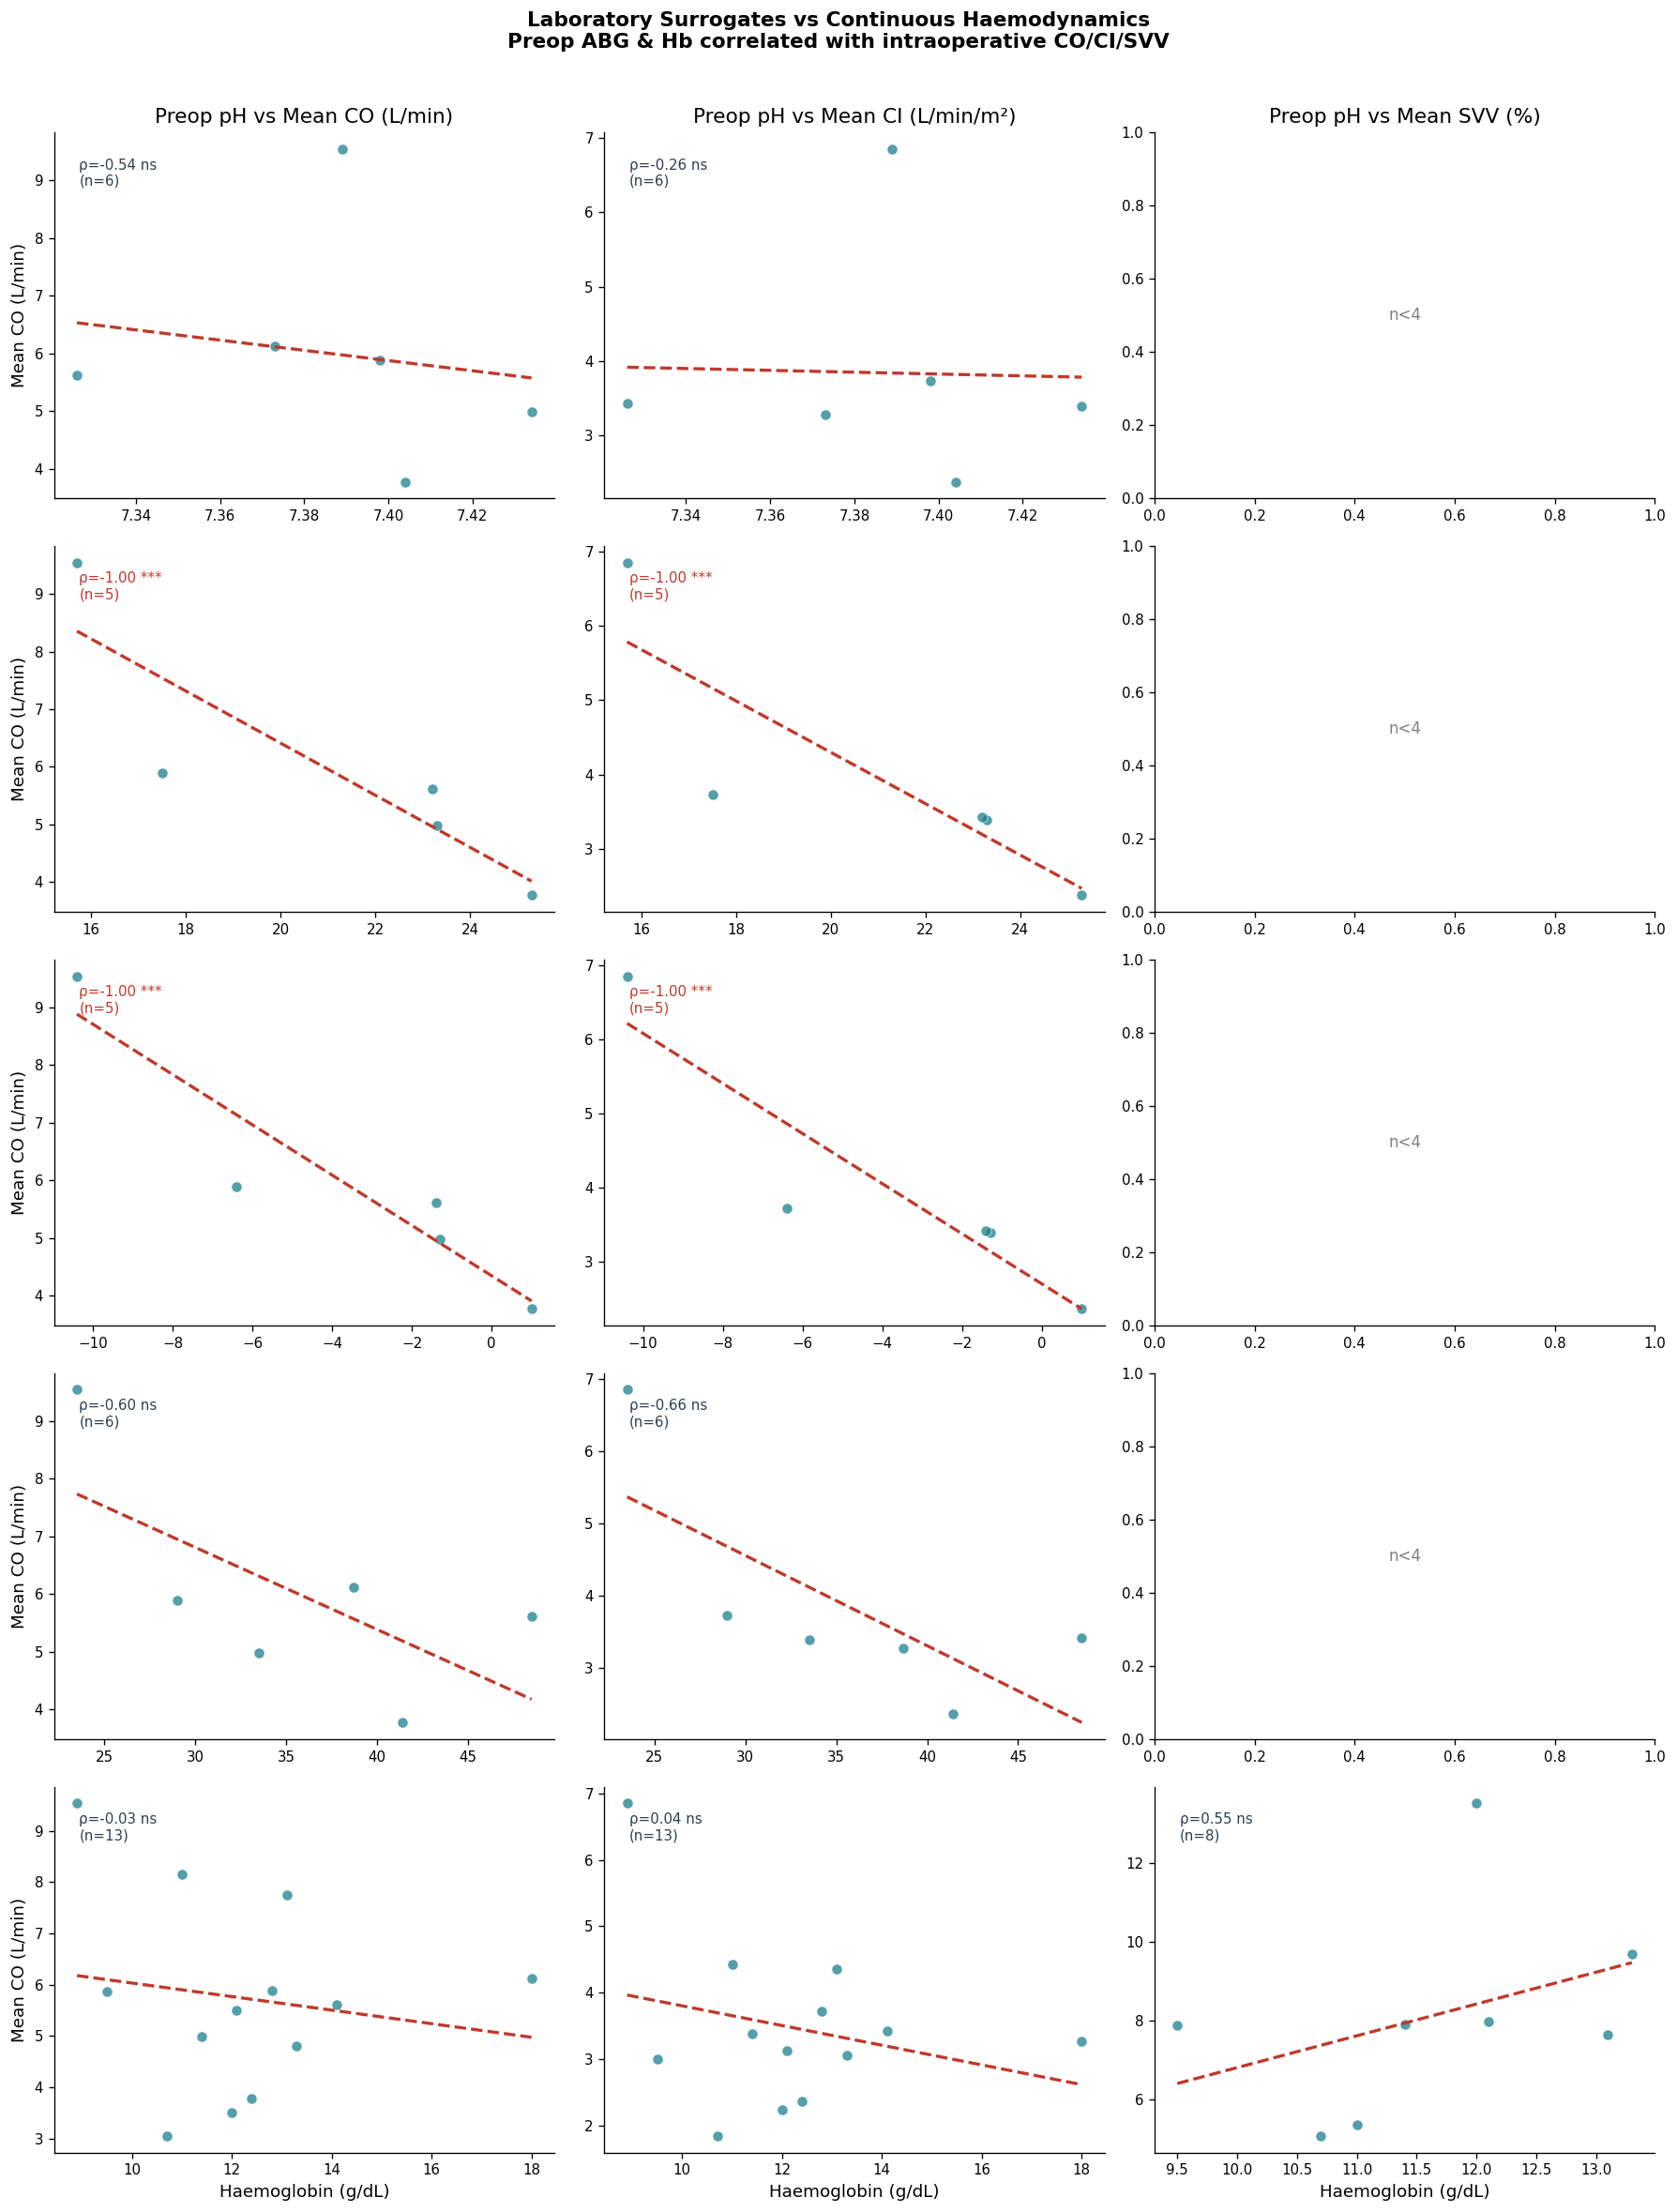

In [5]:
# ── Cell 5: Lab surrogates vs Continuous CO — the cross-sectional correlation ─
cs_labs = cs.copy()

# Extend with up to 5 additional cross-sectional cases not already fetched
EXTEND_MAX = 5
already = set(cs['caseid'].values)
need    = [c for c in xsect['caseid'].values if c not in already][:EXTEND_MAX]
print(f'Extending to up to {EXTEND_MAX} additional cross-sectional cases...')
extra = []
for cid in need:
    row = ev_co[ev_co['caseid']==cid]
    if len(row) == 0: continue
    df = fetch_track(row.iloc[0]['tid'], label='co')
    if df is None: continue
    co_v = df['co'][(df['co']>1)&(df['co']<15)]
    if len(co_v) < 10: continue
    r2 = ev_ci[ev_ci['caseid']==cid]
    ci_mean = None
    if len(r2):
        df2 = fetch_track(r2.iloc[0]['tid'], label='ci')
        if df2 is not None:
            ci_mean = df2['ci'][(df2['ci']>0.5)&(df2['ci']<8)].mean()
    extra.append({'caseid':cid,'co_mean':co_v.mean(),'co_min':co_v.min(),
                  'co_std':co_v.std(),'ci_mean':ci_mean})
    print(f'  +{cid}: CO={co_v.mean():.1f}')
if extra:
    ex_df = pd.DataFrame(extra)
    ex_df = ex_df.merge(cases[['caseid']+LAB_COLS+['preop_hct']], on='caseid', how='left')
    cs_labs = pd.concat([cs_labs, ex_df], ignore_index=True).drop_duplicates('caseid')

print(f'\nCross-sectional cohort with CO+labs: {len(cs_labs.dropna(subset=["co_mean","preop_ph"]))}')

# ── Scatter matrix ────────────────────────────────────────────────────────────
labs_for_plot = [c for c in ['preop_ph','preop_hco3','preop_be','preop_paco2','preop_hb'] if c in cs_labs.columns]
hd_for_plot   = [c for c in ['co_mean','ci_mean','svv_mean'] if c in cs_labs.columns]
lab_labels    = {'preop_ph':'Preop pH','preop_hco3':'HCO₃ (mEq/L)','preop_be':'Base Excess',
                 'preop_paco2':'PaCO₂ (mmHg)','preop_hb':'Haemoglobin (g/dL)'}
hd_labels     = {'co_mean':'Mean CO (L/min)','ci_mean':'Mean CI (L/min/m²)','svv_mean':'Mean SVV (%)'}

n_labs = len(labs_for_plot)
n_hd   = len(hd_for_plot)
fig, axes = plt.subplots(n_labs, n_hd, figsize=(5*n_hd, 4*n_labs))
fig.patch.set_facecolor('white')
if n_labs == 1: axes = [axes]
if n_hd == 1:   axes = [[ax] for ax in axes]

for i, lab in enumerate(labs_for_plot):
    for j, hd in enumerate(hd_for_plot):
        ax = axes[i][j]
        d  = cs_labs[[lab, hd]].dropna()
        if len(d) < 4:
            ax.text(0.5,0.5,'n<4',ha='center',va='center',transform=ax.transAxes,color='gray')
            ax.set_title(f'{lab_labels.get(lab,lab)} vs {hd_labels.get(hd,hd)}' if i==0 else '')
            continue
        x, y = d[lab].values, d[hd].values
        ax.scatter(x, y, s=45, alpha=0.75, color=TEAL, edgecolors='white', lw=0.5)
        try:
            m_, b_, *_ = linregress(x, y)
            xl = np.linspace(x.min(), x.max(), 50)
            ax.plot(xl, m_*xl+b_, color=CRIMSON, lw=2, ls='--')
            rho, prho = spearmanr(x, y)
            sig = '***' if prho<0.001 else ('**' if prho<0.01 else ('*' if prho<0.05 else 'ns'))
            ax.text(0.05, 0.93, f'ρ={rho:.2f} {sig}\n(n={len(d)})',
                    transform=ax.transAxes, fontsize=9, va='top',
                    color=CRIMSON if prho<0.05 else SLATE)
        except Exception:
            pass
        ax.set(xlabel=lab_labels.get(lab,lab) if i==n_labs-1 else '',
               ylabel=hd_labels.get(hd,hd) if j==0 else '',
               title=f'{lab_labels.get(lab,lab)} vs {hd_labels.get(hd,hd)}' if i==0 else '')

plt.suptitle('Laboratory Surrogates vs Continuous Haemodynamics\n'
             'Preop ABG & Hb correlated with intraoperative CO/CI/SVV',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_fig('03_lab_vs_co_scatter')
plt.show()

  Saved: 04_fick_principle.png


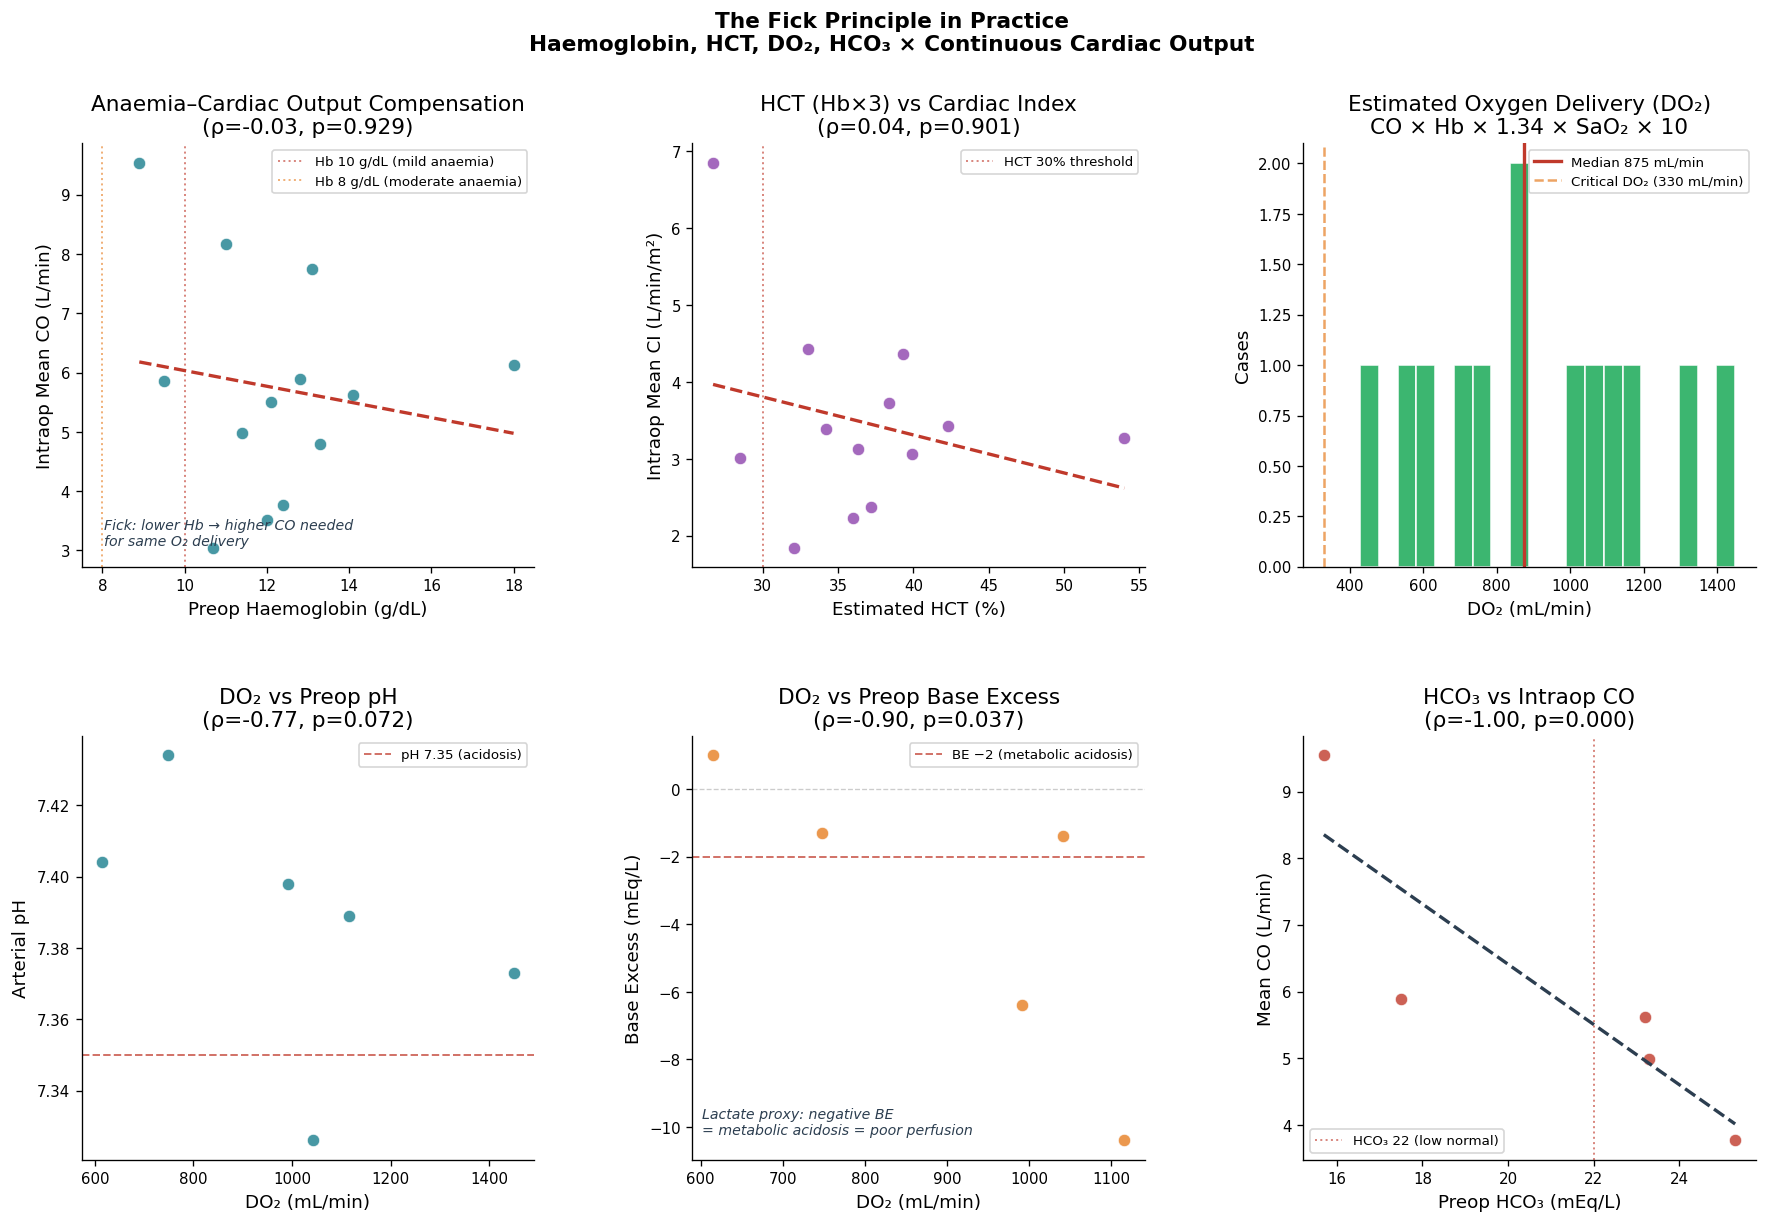

In [6]:
# ── Cell 6: The Fick Principle — HCT/Hb × CO = DO₂ ──────────────────────────
# DO2 = CO × (Hb × 1.34 × SaO2 × 10) + (0.003 × PaO2 × CO)
# Use preop_hb, assume SaO2=0.98, preop_pao2 where available
# This is the key physiological relationship: anaemic patients MUST compensate with higher CO

SaO2 = 0.98
cs_labs['do2_est'] = np.where(
    cs_labs['preop_hb'].notna() & cs_labs['preop_pao2'].notna(),
    cs_labs['co_mean'] * (cs_labs['preop_hb'] * 1.34 * SaO2 * 10 + 0.003 * cs_labs['preop_pao2']),
    cs_labs['co_mean'] * cs_labs['preop_hb'] * 1.34 * SaO2 * 10  # ignore dissolved if PaO2 missing
)

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor('white')

# ── 1: Hb vs CO (compensation curve) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
d = cs_labs.dropna(subset=['preop_hb','co_mean'])
sc = ax1.scatter(d['preop_hb'], d['co_mean'], s=55, alpha=0.8, color=TEAL, edgecolors='white', lw=0.5)
rho, p = spearmanr(d['preop_hb'], d['co_mean'])
try:
    m, b, *_ = linregress(d['preop_hb'], d['co_mean'])
    xl = np.linspace(d['preop_hb'].min(), d['preop_hb'].max(), 50)
    ax1.plot(xl, m*xl+b, color=CRIMSON, lw=2, ls='--')
except: pass
ax1.axvline(10, color=CRIMSON, ls=':', lw=1.2, alpha=0.6, label='Hb 10 g/dL (mild anaemia)')
ax1.axvline(8,  color=AMBER,   ls=':', lw=1.2, alpha=0.6, label='Hb 8 g/dL (moderate anaemia)')
ax1.set(title=f'Anaemia–Cardiac Output Compensation\n(ρ={rho:.2f}, p={p:.3f})',
        xlabel='Preop Haemoglobin (g/dL)', ylabel='Intraop Mean CO (L/min)')
ax1.legend(fontsize=8)
ax1.text(0.05, 0.05, 'Fick: lower Hb → higher CO needed\nfor same O₂ delivery', transform=ax1.transAxes,
         fontsize=8.5, color=SLATE, style='italic')

# ── 2: HCT (Hb×3) vs CI ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
d2 = cs_labs.dropna(subset=['preop_hct','ci_mean'])
if len(d2) > 3:
    ax2.scatter(d2['preop_hct'], d2['ci_mean'], s=55, alpha=0.8, color=PURPLE, edgecolors='white', lw=0.5)
    rho2, p2 = spearmanr(d2['preop_hct'], d2['ci_mean'])
    try:
        m2, b2, *_ = linregress(d2['preop_hct'], d2['ci_mean'])
        xl2 = np.linspace(d2['preop_hct'].min(), d2['preop_hct'].max(), 50)
        ax2.plot(xl2, m2*xl2+b2, color=CRIMSON, lw=2, ls='--')
    except: pass
    ax2.axvline(30, color=CRIMSON, ls=':', lw=1.2, alpha=0.6, label='HCT 30% threshold')
    ax2.set(title=f'HCT (Hb×3) vs Cardiac Index\n(ρ={rho2:.2f}, p={p2:.3f})',
            xlabel='Estimated HCT (%)', ylabel='Intraop Mean CI (L/min/m²)')
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5,0.5,'Insufficient\nHb/HCT data',ha='center',va='center',transform=ax2.transAxes)
    ax2.set_title('HCT vs CI')

# ── 3: Estimated DO₂ distribution ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
do2_vals = cs_labs['do2_est'].dropna()
do2_vals = do2_vals[(do2_vals > 100) & (do2_vals < 2000)]
if len(do2_vals) > 3:
    ax3.hist(do2_vals, bins=20, color=GREEN, edgecolor='white', alpha=0.9)
    ax3.axvline(do2_vals.median(), color=CRIMSON, lw=2, label=f'Median {do2_vals.median():.0f} mL/min')
    ax3.axvline(330, color=AMBER, ls='--', lw=1.5, alpha=0.7, label='Critical DO₂ (330 mL/min)')
    ax3.set(title='Estimated Oxygen Delivery (DO₂)\nCO × Hb × 1.34 × SaO₂ × 10',
            xlabel='DO₂ (mL/min)', ylabel='Cases')
    ax3.legend(fontsize=8)

# ── 4: DO₂ vs pH — oxygen delivery and acid-base ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
d4 = cs_labs.dropna(subset=['do2_est','preop_ph'])
d4 = d4[(d4['do2_est']>100)&(d4['do2_est']<2000)]
if len(d4) > 3:
    ax4.scatter(d4['do2_est'], d4['preop_ph'], s=55, alpha=0.8, color=TEAL, edgecolors='white', lw=0.5)
    rho4, p4 = spearmanr(d4['do2_est'], d4['preop_ph'])
    ax4.axhline(7.35, color=CRIMSON, ls='--', lw=1.2, alpha=0.7, label='pH 7.35 (acidosis)')
    ax4.set(title=f'DO₂ vs Preop pH\n(ρ={rho4:.2f}, p={p4:.3f})',
            xlabel='DO₂ (mL/min)', ylabel='Arterial pH')
    ax4.legend(fontsize=8)

# ── 5: DO₂ vs BE ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
d5 = cs_labs.dropna(subset=['do2_est','preop_be'])
d5 = d5[(d5['do2_est']>100)&(d5['do2_est']<2000)]
if len(d5) > 3:
    ax5.scatter(d5['do2_est'], d5['preop_be'], s=55, alpha=0.8, color=AMBER, edgecolors='white', lw=0.5)
    rho5, p5 = spearmanr(d5['do2_est'], d5['preop_be'])
    ax5.axhline(-2, color=CRIMSON, ls='--', lw=1.2, alpha=0.7, label='BE −2 (metabolic acidosis)')
    ax5.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax5.set(title=f'DO₂ vs Preop Base Excess\n(ρ={rho5:.2f}, p={p5:.3f})',
            xlabel='DO₂ (mL/min)', ylabel='Base Excess (mEq/L)')
    ax5.legend(fontsize=8)
    ax5.text(0.02, 0.06, 'Lactate proxy: negative BE\n= metabolic acidosis = poor perfusion',
             transform=ax5.transAxes, fontsize=8.5, color=SLATE, style='italic')

# ── 6: HCO₃ vs CO ────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
d6 = cs_labs.dropna(subset=['preop_hco3','co_mean'])
if len(d6) > 3:
    ax6.scatter(d6['preop_hco3'], d6['co_mean'], s=55, alpha=0.8, color=CRIMSON, edgecolors='white', lw=0.5)
    rho6, p6 = spearmanr(d6['preop_hco3'], d6['co_mean'])
    try:
        m6, b6, *_ = linregress(d6['preop_hco3'], d6['co_mean'])
        xl6 = np.linspace(d6['preop_hco3'].min(), d6['preop_hco3'].max(), 50)
        ax6.plot(xl6, m6*xl6+b6, color=SLATE, lw=2, ls='--')
    except: pass
    ax6.axvline(22, color=CRIMSON, ls=':', lw=1.2, alpha=0.6, label='HCO₃ 22 (low normal)')
    ax6.set(title=f'HCO₃ vs Intraop CO\n(ρ={rho6:.2f}, p={p6:.3f})',
            xlabel='Preop HCO₃ (mEq/L)', ylabel='Mean CO (L/min)')
    ax6.legend(fontsize=8)

plt.suptitle('The Fick Principle in Practice\nHaemoglobin, HCT, DO₂, HCO₃ × Continuous Cardiac Output',
             fontsize=13, fontweight='bold')
save_fig('04_fick_principle')
plt.show()

CO–ETCO2 paired cases: 8
Median ρ = 0.03  |  Mean ρ = 0.09
% positive correlation: 50%
  Saved: 05_etco2_co_coupling.png


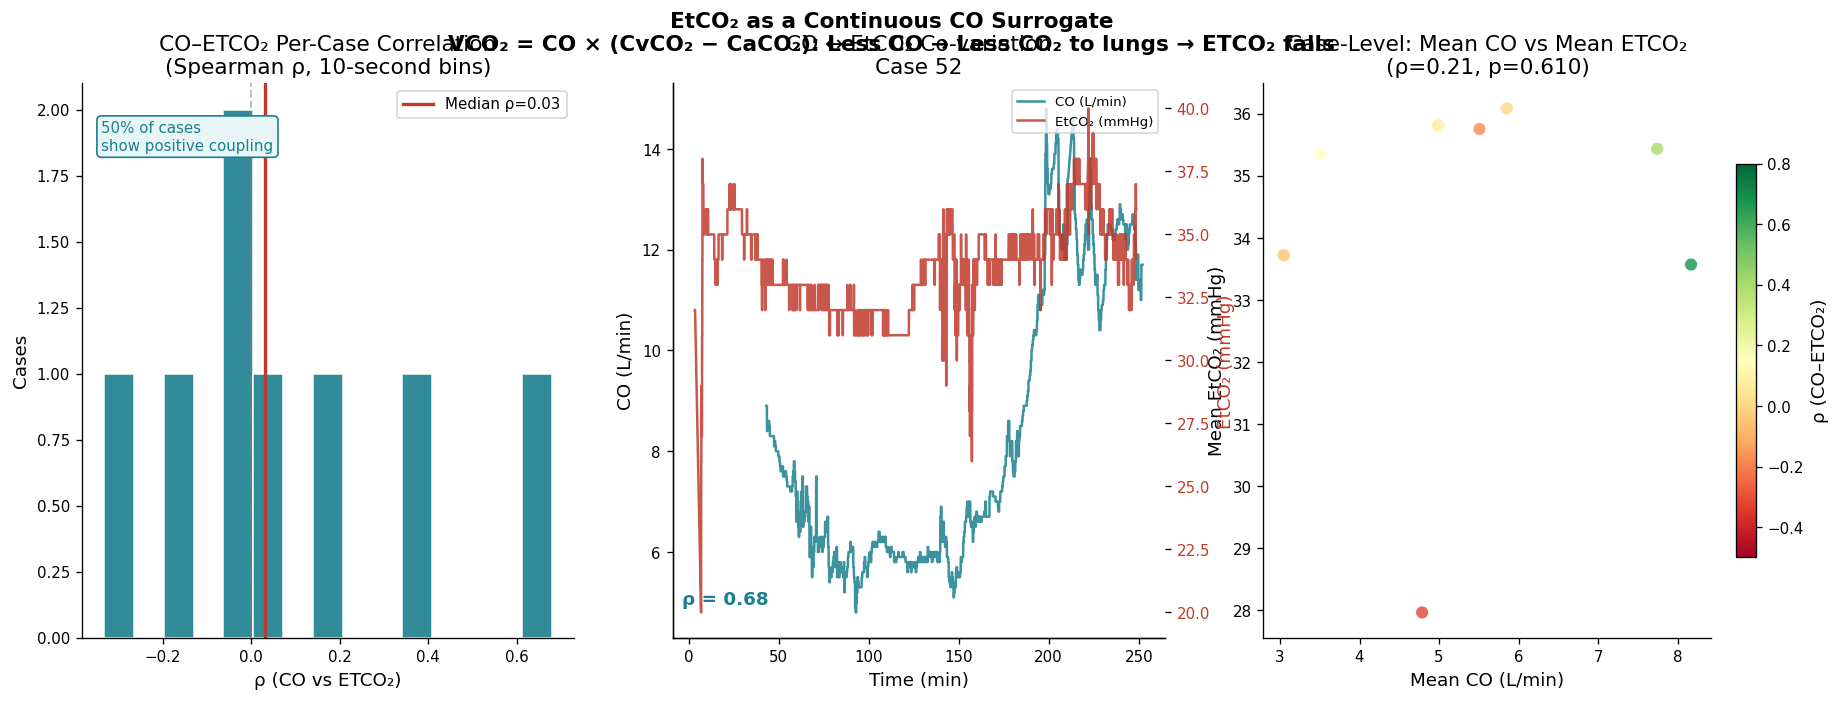

In [7]:
# ── Cell 7: ETCO₂ as continuous CO surrogate — the CO×ETCO₂ coupling ─────────
# Physiological basis: VCO2 = CO × (CvCO2 - CaCO2)
# If ventilation is constant → ETCO2 ∝ CO × mixed venous CO2 content
# Expected: ETCO2 ↓ when CO ↓ (less CO2 delivered to lungs)

# For each fetched case with BOTH CO and ETCO2, merge on time and compute correlation
etco2_co_corrs = []

for cid, entry in fetched.items():
    if 'co' not in entry or 'etco2' not in entry:
        continue
    df_co   = entry['co'].dropna()
    df_etco = entry['etco2'].dropna()
    # Filter physiological ranges
    df_co   = df_co[(df_co['co']>1)&(df_co['co']<15)].copy()
    df_etco = df_etco[(df_etco['etco2']>15)&(df_etco['etco2']<60)].copy()
    if len(df_co) < 20 or len(df_etco) < 20: continue
    # Merge: resample CO to same time grid as ETCO2
    t_min_e = max(df_co['time_s'].min(), df_etco['time_s'].min())
    t_max_e = min(df_co['time_s'].max(), df_etco['time_s'].max())
    if t_max_e - t_min_e < 600: continue   # < 10 min overlap
    # Align to 10-s bins
    t_bins = np.arange(t_min_e, t_max_e, 10)
    co_r   = np.interp(t_bins, df_co['time_s'].values, df_co['co'].values)
    et_r   = np.interp(t_bins, df_etco['time_s'].values, df_etco['etco2'].values)
    if len(co_r) < 10: continue
    rho, p = spearmanr(co_r, et_r)
    etco2_co_corrs.append({'caseid': cid, 'rho': rho, 'p': p, 'n': len(t_bins),
                            'co_mean': np.mean(co_r), 'etco2_mean': np.mean(et_r)})

corr_df = pd.DataFrame(etco2_co_corrs)
print(f'CO–ETCO2 paired cases: {len(corr_df)}')
if len(corr_df) > 0:
    print(f'Median ρ = {corr_df["rho"].median():.2f}  |  Mean ρ = {corr_df["rho"].mean():.2f}')
    print(f'% positive correlation: {100*np.mean(corr_df["rho"]>0):.0f}%')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

# 1: Distribution of rho values
ax = axes[0]
if len(corr_df) > 2:
    ax.hist(corr_df['rho'], bins=15, color=TEAL, edgecolor='white', alpha=0.9)
    ax.axvline(0, color='gray', ls='--', lw=1.2, alpha=0.5)
    ax.axvline(corr_df['rho'].median(), color=CRIMSON, lw=2,
               label=f'Median ρ={corr_df["rho"].median():.2f}')
    ax.set(title='CO–ETCO₂ Per-Case Correlation\n(Spearman ρ, 10-second bins)',
           xlabel='ρ (CO vs ETCO₂)', ylabel='Cases')
    ax.legend(fontsize=9)
    ax.text(0.04, 0.88, f'{100*np.mean(corr_df["rho"]>0):.0f}% of cases\nshow positive coupling',
            transform=ax.transAxes, fontsize=9, color=TEAL,
            bbox=dict(boxstyle='round', facecolor='#E8F5F7', edgecolor=TEAL))
else:
    ax.text(0.5,0.5,'Insufficient paired data',ha='center',va='center',transform=ax.transAxes)

# 2: Overlay CO and ETCO2 for the case with strongest positive correlation
ax = axes[1]
if len(corr_df) > 0:
    best_cid = int(corr_df.sort_values('rho', ascending=False).iloc[0]['caseid'])
    entry_b  = fetched[best_cid]
    df_co_b  = entry_b['co'][(entry_b['co']['co']>1)&(entry_b['co']['co']<15)].copy()
    df_et_b  = entry_b['etco2'][(entry_b['etco2']['etco2']>15)&(entry_b['etco2']['etco2']<60)].copy()
    t_m_co   = df_co_b['time_s'].values / 60
    t_m_et   = df_et_b['time_s'].values / 60

    ax2r = ax.twinx()
    lco, = ax.plot(t_m_co,  df_co_b['co'],    lw=1.5, color=TEAL,   alpha=0.85, label='CO (L/min)')
    let, = ax2r.plot(t_m_et, df_et_b['etco2'], lw=1.5, color=CRIMSON, alpha=0.85, label='EtCO₂ (mmHg)')
    ax.set(xlabel='Time (min)', ylabel='CO (L/min)', title=f'CO ↔ EtCO₂ Co-variation\nCase {best_cid}')
    ax2r.set_ylabel('EtCO₂ (mmHg)', color=CRIMSON)
    ax2r.tick_params(axis='y', labelcolor=CRIMSON)
    rho_b = corr_df[corr_df['caseid']==best_cid]['rho'].values[0]
    ax.text(0.02, 0.06, f'ρ = {rho_b:.2f}', transform=ax.transAxes, fontsize=11,
            color=TEAL, fontweight='bold')
    ax.legend(handles=[lco,let], loc='upper right', fontsize=8)
    ax.set_facecolor('white')

# 3: Mean CO vs mean ETCO2 across cases (case-level scatter)
ax = axes[2]
if len(corr_df) > 3:
    ax.scatter(corr_df['co_mean'], corr_df['etco2_mean'], s=60, alpha=0.8,
               c=corr_df['rho'], cmap='RdYlGn', edgecolors='white', lw=0.5,
               vmin=-0.5, vmax=0.8)
    plt.colorbar(plt.cm.ScalarMappable(norm=mcolors.Normalize(-0.5, 0.8), cmap='RdYlGn'),
                 ax=ax, fraction=0.04, label='ρ (CO–ETCO₂)')
    rho_m, p_m = spearmanr(corr_df['co_mean'], corr_df['etco2_mean'])
    ax.set(title=f'Case-Level: Mean CO vs Mean ETCO₂\n(ρ={rho_m:.2f}, p={p_m:.3f})',
           xlabel='Mean CO (L/min)', ylabel='Mean EtCO₂ (mmHg)')

plt.suptitle('EtCO₂ as a Continuous CO Surrogate\n'
             'VCO₂ = CO × (CvCO₂ − CaCO₂): Less CO → Less CO₂ to lungs → ETCO₂ falls',
             fontsize=13, fontweight='bold')
save_fig('05_etco2_co_coupling')
plt.show()

  Saved: 06_svv_analysis.png


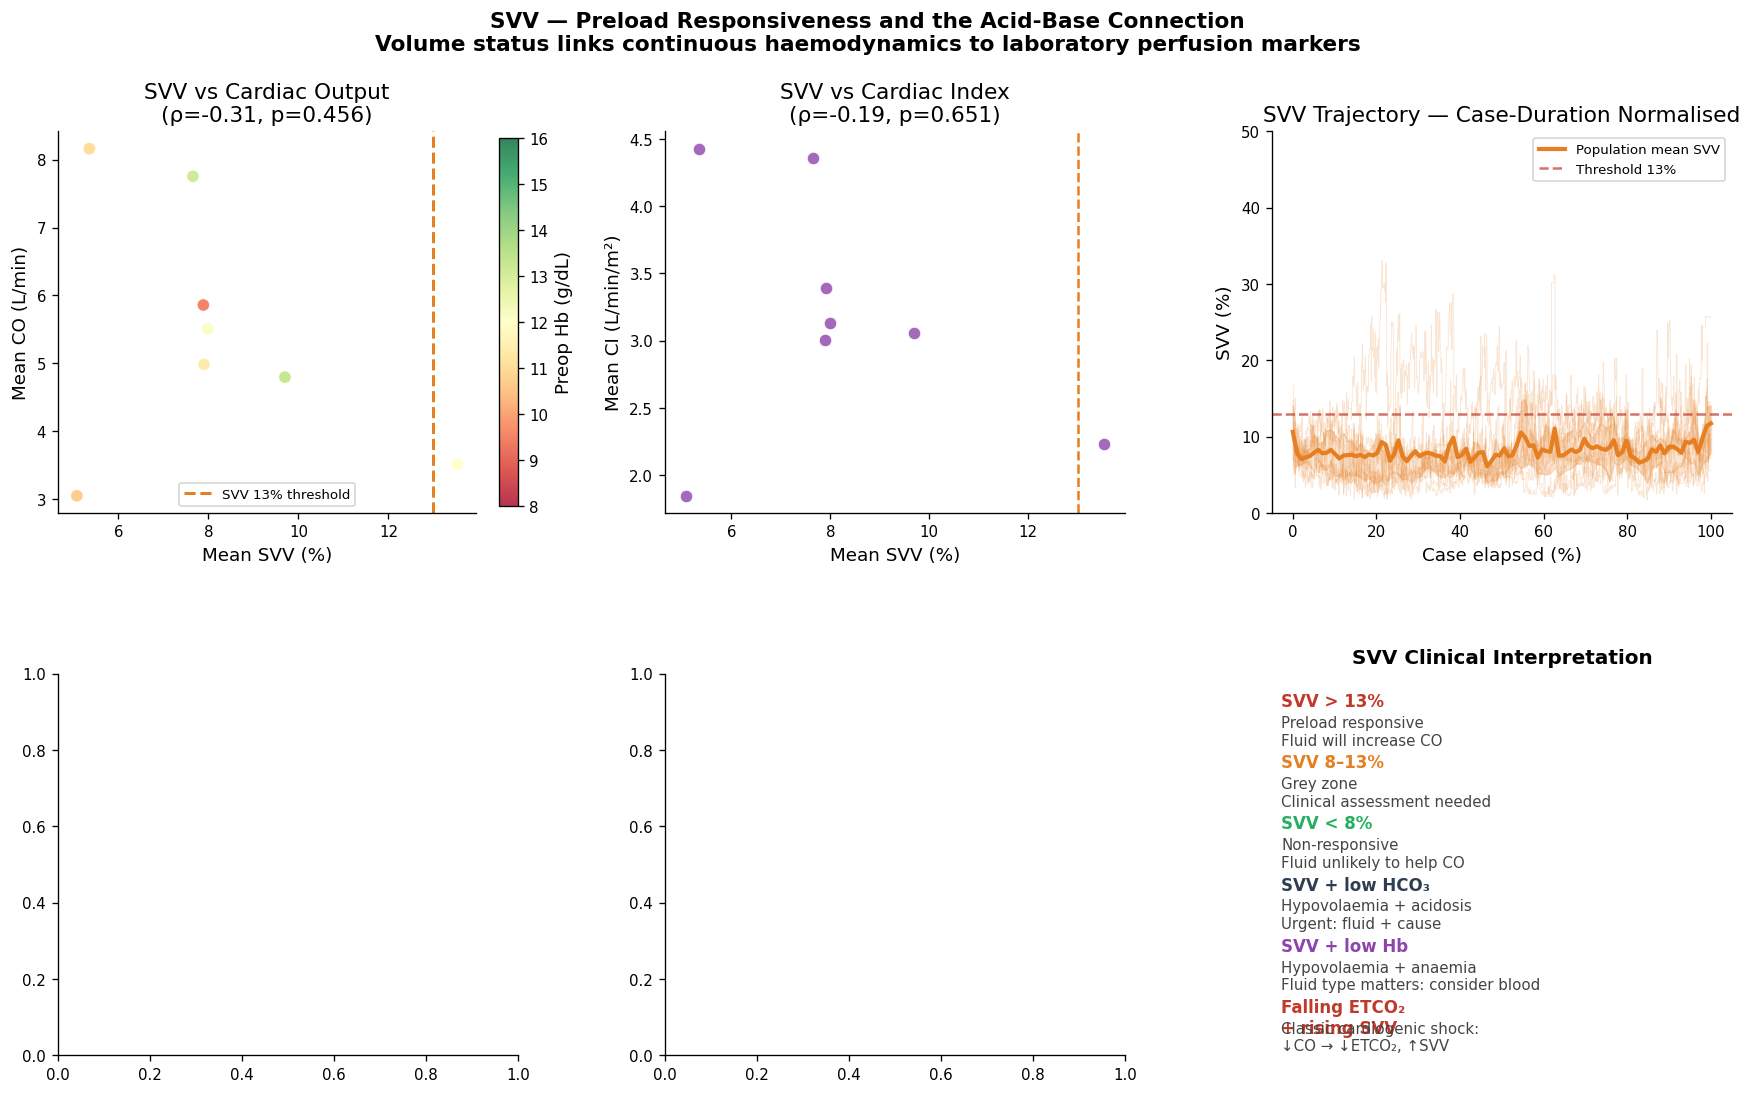

In [8]:
# ── Cell 8: SVV dynamics — preload responsiveness & the CO response ───────────
# SVV > 13%: patient is preload-responsive (will augment CO with fluid)
# This cell characterises the SVV–CO relationship and SVV dynamics over time

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
fig.patch.set_facecolor('white')

# ── 1: SVV vs CO scatter ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
d = cs_labs.dropna(subset=['svv_mean','co_mean'])
if len(d) > 3:
    sc = ax1.scatter(d['svv_mean'], d['co_mean'], s=55, alpha=0.8,
                     c=d.get('preop_hb', pd.Series([TEAL]*len(d))),
                     cmap='RdYlGn', edgecolors='white', lw=0.5, vmin=8, vmax=16)
    if 'preop_hb' in d.columns:
        plt.colorbar(sc, ax=ax1, fraction=0.04, label='Preop Hb (g/dL)')
    rho, p = spearmanr(d['svv_mean'], d['co_mean'])
    ax1.axvline(13, color=AMBER, ls='--', lw=1.8, label='SVV 13% threshold')
    ax1.set(title=f'SVV vs Cardiac Output\n(ρ={rho:.2f}, p={p:.3f})',
            xlabel='Mean SVV (%)', ylabel='Mean CO (L/min)')
    ax1.legend(fontsize=8)

# ── 2: SVV vs CI ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
d2 = cs_labs.dropna(subset=['svv_mean','ci_mean'])
if len(d2) > 3:
    ax2.scatter(d2['svv_mean'], d2['ci_mean'], s=55, alpha=0.8, color=PURPLE, edgecolors='white', lw=0.5)
    rho2, p2 = spearmanr(d2['svv_mean'], d2['ci_mean'])
    ax2.axvline(13, color=AMBER, ls='--', lw=1.5)
    # High vs low SVV boxplot overlay
    hi_svv = d2[d2['svv_mean']>=13]['ci_mean']
    lo_svv = d2[d2['svv_mean']<13]['ci_mean']
    ax2.set(title=f'SVV vs Cardiac Index\n(ρ={rho2:.2f}, p={p2:.3f})',
            xlabel='Mean SVV (%)', ylabel='Mean CI (L/min/m²)')
    if len(hi_svv) > 1 and len(lo_svv) > 1:
        from scipy.stats import mannwhitneyu as mwu
        stat, pv = mwu(hi_svv, lo_svv, alternative='two-sided')
        ax2.text(0.5, 0.94, f'SVV≥13: CI={hi_svv.mean():.2f} vs SVV<13: CI={lo_svv.mean():.2f}\np={pv:.3f}',
                 transform=ax2.transAxes, ha='center', fontsize=8.5, color=SLATE)

# ── 3: SVV over time (spaghetti + mean trajectory) ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
svv_trajs = []
for cid, entry in fetched.items():
    if 'svv' not in entry: continue
    df_s  = entry['svv'].dropna()
    svv_v = df_s['svv'][(df_s['svv']>=0)&(df_s['svv']<=60)].reset_index(drop=True)
    t_s   = df_s['time_s'][(df_s['svv']>=0)&(df_s['svv']<=60)].reset_index(drop=True)
    if len(svv_v) < 20: continue
    t_pct = 100*(t_s - t_s.min())/(t_s.max()-t_s.min()+1)
    ax3.plot(t_pct, svv_v.values, lw=0.5, alpha=0.2, color=AMBER)
    f = interp1d(t_pct, svv_v.values, kind='linear', bounds_error=False, fill_value='extrapolate')
    svv_trajs.append(f(np.linspace(0,100,100)))
if svv_trajs:
    svv_arr = np.array(svv_trajs)
    ax3.plot(np.linspace(0,100,100), svv_arr.mean(axis=0), lw=2.5, color=AMBER, label='Population mean SVV')
    ax3.fill_between(np.linspace(0,100,100),
                     np.percentile(svv_arr,25,axis=0), np.percentile(svv_arr,75,axis=0),
                     color=AMBER, alpha=0.2)
ax3.axhline(13, color=CRIMSON, ls='--', lw=1.5, alpha=0.7, label='Threshold 13%')
ax3.set(title='SVV Trajectory — Case-Duration Normalised',
        xlabel='Case elapsed (%)', ylabel='SVV (%)', ylim=(0, 50))
ax3.legend(fontsize=8)

# ── 4: SVV vs HCO₃ — volume status and acid-base ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
d4 = cs_labs.dropna(subset=['svv_mean','preop_hco3'])
if len(d4) > 3:
    ax4.scatter(d4['svv_mean'], d4['preop_hco3'], s=55, alpha=0.8, color=TEAL, edgecolors='white', lw=0.5)
    rho4, p4 = spearmanr(d4['svv_mean'], d4['preop_hco3'])
    ax4.axvline(13, color=AMBER, ls='--', lw=1.5)
    ax4.axhline(22, color=CRIMSON, ls=':', lw=1.2, alpha=0.6)
    ax4.set(title=f'SVV vs Preop HCO₃\n(ρ={rho4:.2f}, p={p4:.3f})',
            xlabel='Mean SVV (%)', ylabel='HCO₃ (mEq/L)')
    ax4.text(0.02, 0.06, 'High SVV = hypovolaemia\nLow HCO₃ = metabolic acidosis\n→ both signal poor perfusion',
             transform=ax4.transAxes, fontsize=8, color=SLATE, style='italic')

# ── 5: SVV vs BE ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
d5 = cs_labs.dropna(subset=['svv_mean','preop_be'])
if len(d5) > 3:
    ax5.scatter(d5['svv_mean'], d5['preop_be'], s=55, alpha=0.8, color=AMBER, edgecolors='white', lw=0.5)
    rho5, p5 = spearmanr(d5['svv_mean'], d5['preop_be'])
    ax5.axvline(13, color=AMBER, ls='--', lw=1.5)
    ax5.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax5.axhline(-2, color=CRIMSON, ls=':', lw=1.2, alpha=0.6, label='BE −2 threshold')
    ax5.set(title=f'SVV vs Base Excess (lactate proxy)\n(ρ={rho5:.2f}, p={p5:.3f})',
            xlabel='Mean SVV (%)', ylabel='Base Excess (mEq/L)')
    ax5.legend(fontsize=8)

# ── 6: Summary box ───────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_title('SVV Clinical Interpretation', fontsize=12, fontweight='bold')
concepts = [
    ('SVV > 13%',     CRIMSON, 'Preload responsive\nFluid will increase CO'),
    ('SVV 8–13%',     AMBER,   'Grey zone\nClinical assessment needed'),
    ('SVV < 8%',      GREEN,   'Non-responsive\nFluid unlikely to help CO'),
    ('SVV + low HCO₃',SLATE,   'Hypovolaemia + acidosis\nUrgent: fluid + cause'),
    ('SVV + low Hb',  PURPLE,  'Hypovolaemia + anaemia\nFluid type matters: consider blood'),
    ('Falling ETCO₂\n+ rising SVV', '#C0392B', 'Classic cardiogenic shock:\n↓CO → ↓ETCO₂, ↑SVV'),
]
for i, (cond, col, detail) in enumerate(concepts):
    y = 0.95 - i * 0.16
    ax6.text(0.02, y, cond, transform=ax6.transAxes, fontsize=10,
             fontweight='bold', color=col, va='top')
    ax6.text(0.02, y-0.06, detail, transform=ax6.transAxes, fontsize=9,
             color='#444', va='top')

plt.suptitle('SVV — Preload Responsiveness and the Acid-Base Connection\n'
             'Volume status links continuous haemodynamics to laboratory perfusion markers',
             fontsize=13, fontweight='bold')
save_fig('06_svv_analysis')
plt.show()

  Saved: 07_correlation_heatmap.png


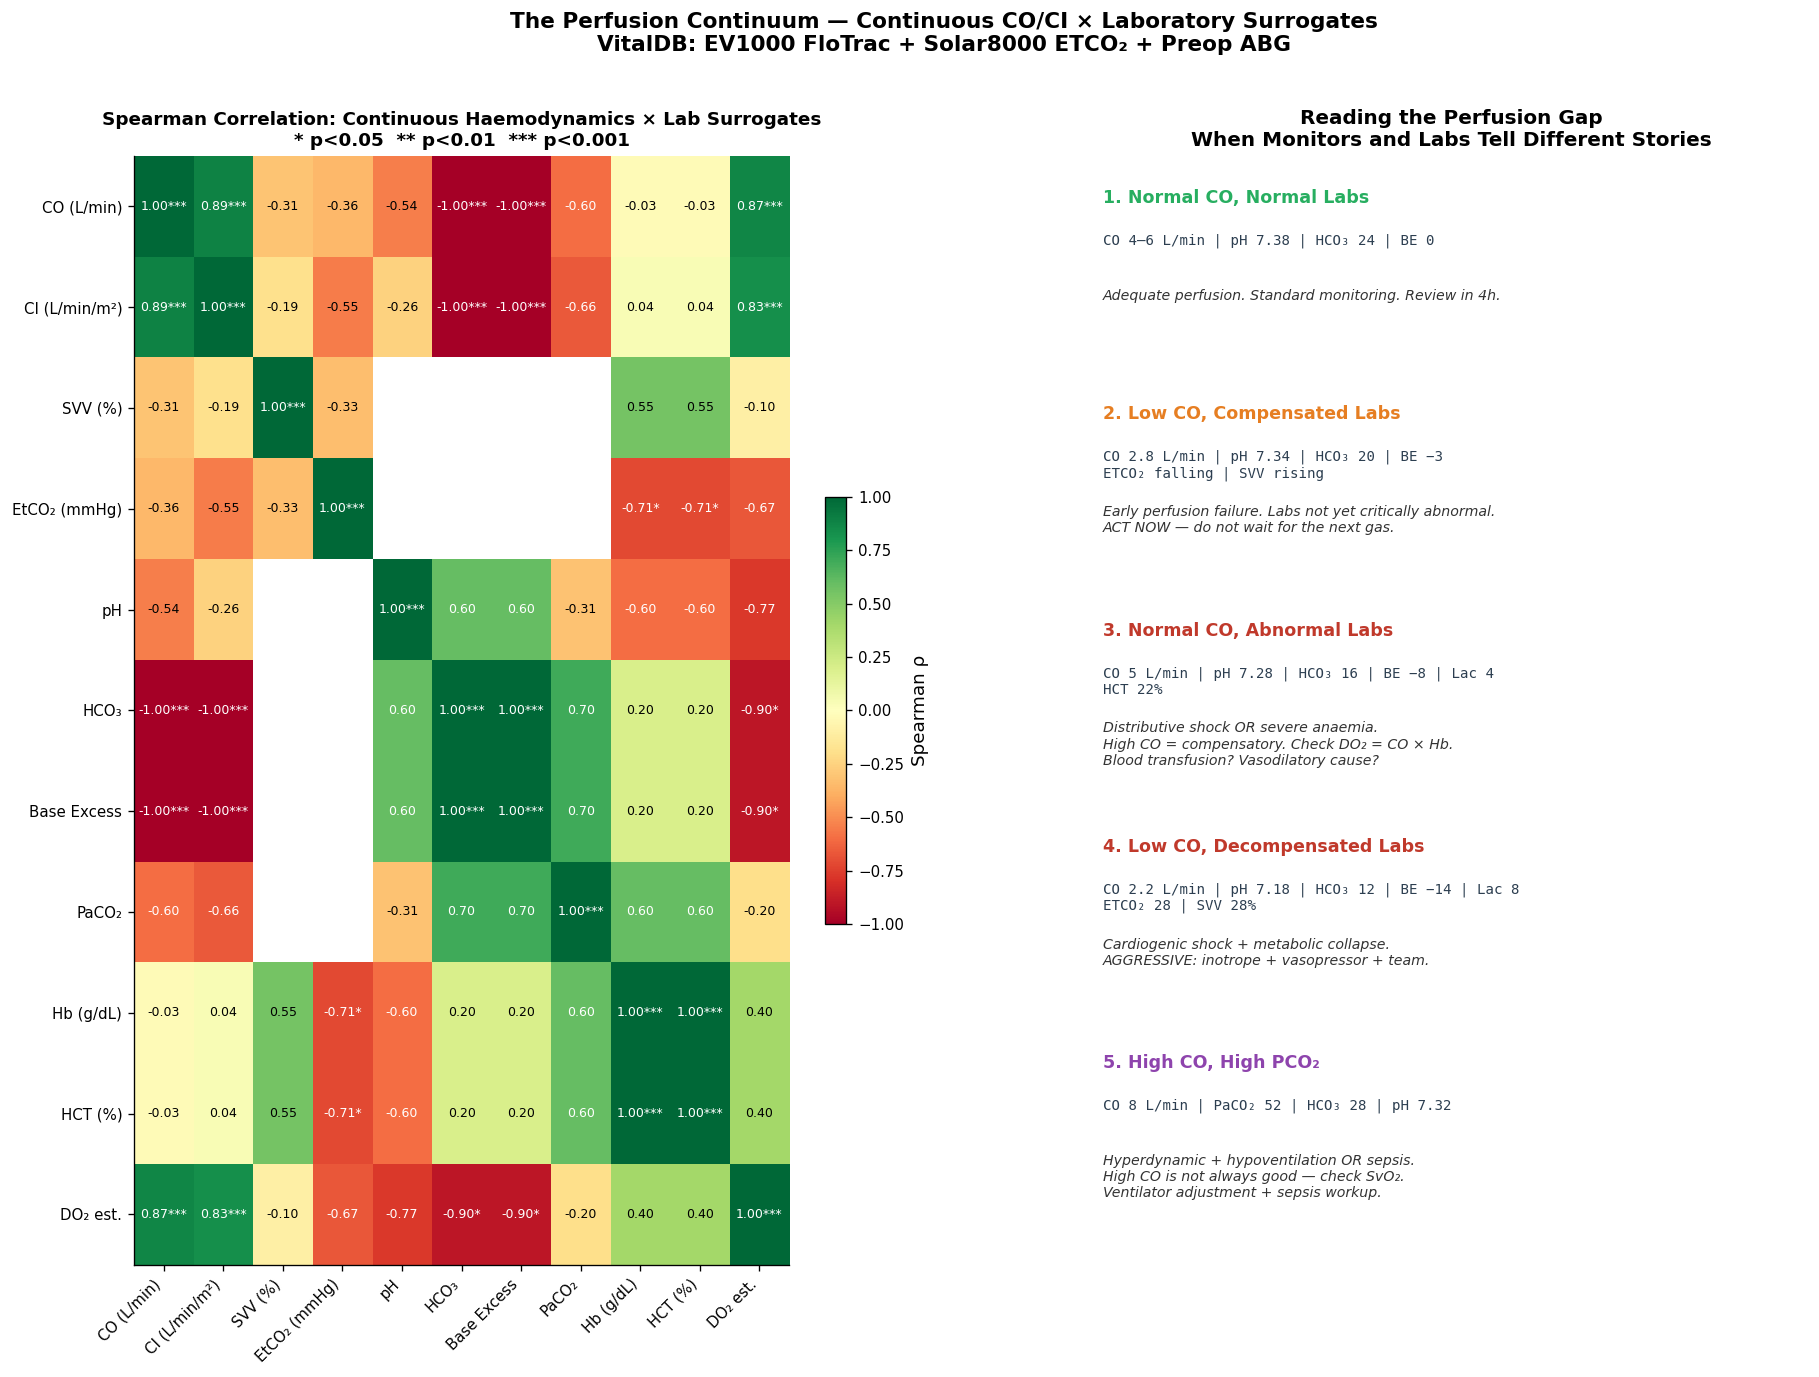


CO–PERFUSION ANALYSIS COMPLETE
Figures → /Volumes/iDrisAI/VitalDBGit/co_figures
  01_perfusion_dashboard.png  (307 KB)
  02_co_ci_population.png  (310 KB)
  03_lab_vs_co_scatter.png  (286 KB)
  04_fick_principle.png  (246 KB)
  05_etco2_co_coupling.png  (171 KB)
  06_svv_analysis.png  (273 KB)
  07_correlation_heatmap.png  (331 KB)

Cohort summary:
  Fetched CO cases   : 8
  Cross-sectional n  : 6 (CO + preop pH)
  CO–ETCO₂ paired    : 8 (median rho=0.03)

Key findings:
  Median CO  : 5.6 L/min
  Median CI  : 3.3 L/min/m²
  Median SVV : 7.9%  (12% cases preload-responsive)
  Note: preop lactate not in VitalDB — Base Excess (BE) used as metabolic acidosis proxy


In [9]:
# ── Cell 9: Correlation heatmap + summary closing figure ─────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
fig.patch.set_facecolor('white')

# ── Left: Full Spearman correlation matrix ────────────────────────────────────
ax_heat = fig.add_subplot(gs[0])
all_cols = [c for c in ['co_mean','ci_mean','svv_mean','etco2_mean',
                          'preop_ph','preop_hco3','preop_be','preop_paco2',
                          'preop_hb','preop_hct','do2_est'] if c in cs_labs.columns]
label_map = {
    'co_mean':    'CO (L/min)', 'ci_mean':   'CI (L/min/m²)',
    'svv_mean':   'SVV (%)',    'etco2_mean':'EtCO₂ (mmHg)',
    'preop_ph':   'pH',         'preop_hco3':'HCO₃',
    'preop_be':   'Base Excess','preop_paco2':'PaCO₂',
    'preop_hb':   'Hb (g/dL)', 'preop_hct':  'HCT (%)',
    'do2_est':    'DO₂ est.',
}
corr_mat = np.full((len(all_cols), len(all_cols)), np.nan)
pval_mat = np.full((len(all_cols), len(all_cols)), np.nan)

for i, c1 in enumerate(all_cols):
    for j, c2 in enumerate(all_cols):
        if i == j:
            corr_mat[i,j] = 1.0; pval_mat[i,j] = 0.0; continue
        d_ = cs_labs[[c1, c2]].dropna()
        if len(d_) < 5: continue
        rho_, p_ = spearmanr(d_[c1], d_[c2])
        corr_mat[i,j] = rho_; pval_mat[i,j] = p_

labels_clean = [label_map.get(c, c) for c in all_cols]
im = ax_heat.imshow(corr_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax_heat.set_xticks(range(len(all_cols))); ax_heat.set_yticks(range(len(all_cols)))
ax_heat.set_xticklabels(labels_clean, rotation=45, ha='right', fontsize=9)
ax_heat.set_yticklabels(labels_clean, fontsize=9)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        rho_v = corr_mat[i,j]
        p_v   = pval_mat[i,j]
        if np.isnan(rho_v): continue
        sig = '***' if p_v<0.001 else ('**' if p_v<0.01 else ('*' if p_v<0.05 else ''))
        txt = f'{rho_v:.2f}{sig}'
        ax_heat.text(j, i, txt, ha='center', va='center', fontsize=7.5,
                     color='white' if abs(rho_v)>0.55 else 'black')
plt.colorbar(im, ax=ax_heat, fraction=0.03, label='Spearman ρ')
ax_heat.set_title('Spearman Correlation: Continuous Haemodynamics × Lab Surrogates\n'
                  '* p<0.05  ** p<0.01  *** p<0.001', fontsize=11, fontweight='bold')

# ── Right: Clinical synthesis ─────────────────────────────────────────────────
ax_syn = fig.add_subplot(gs[1])
ax_syn.set_facecolor('white')
ax_syn.axis('off')
ax_syn.set_title('Reading the Perfusion Gap\nWhen Monitors and Labs Tell Different Stories',
                 fontsize=12, fontweight='bold')

scenarios = [
    ('Normal CO, Normal Labs',    GREEN,
     'CO 4–6 L/min | pH 7.38 | HCO₃ 24 | BE 0',
     'Adequate perfusion. Standard monitoring. Review in 4h.'),
    ('Low CO, Compensated Labs',  AMBER,
     'CO 2.8 L/min | pH 7.34 | HCO₃ 20 | BE −3\nETCO₂ falling | SVV rising',
     'Early perfusion failure. Labs not yet critically abnormal.\nACT NOW — do not wait for the next gas.'),
    ('Normal CO, Abnormal Labs',  '#C0392B',
     'CO 5 L/min | pH 7.28 | HCO₃ 16 | BE −8 | Lac 4\nHCT 22%',
     'Distributive shock OR severe anaemia.\nHigh CO = compensatory. Check DO₂ = CO × Hb.\nBlood transfusion? Vasodilatory cause?'),
    ('Low CO, Decompensated Labs', CRIMSON,
     'CO 2.2 L/min | pH 7.18 | HCO₃ 12 | BE −14 | Lac 8\nETCO₂ 28 | SVV 28%',
     'Cardiogenic shock + metabolic collapse.\nAGGRESSIVE: inotrope + vasopressor + team.'),
    ('High CO, High PCO₂',        PURPLE,
     'CO 8 L/min | PaCO₂ 52 | HCO₃ 28 | pH 7.32',
     'Hyperdynamic + hypoventilation OR sepsis.\nHigh CO is not always good — check SvO₂.\nVentilator adjustment + sepsis workup.'),
]

for i, (title, col, labs, action) in enumerate(scenarios):
    y = 0.97 - i * 0.195
    ax_syn.text(0.01, y, f'{i+1}. {title}', transform=ax_syn.transAxes,
                fontsize=10.5, fontweight='bold', color=col, va='top')
    ax_syn.text(0.01, y-0.04, labs, transform=ax_syn.transAxes,
                fontsize=8.5, color=SLATE, va='top', family='monospace')
    ax_syn.text(0.01, y-0.09, action, transform=ax_syn.transAxes,
                fontsize=8.5, color='#333', va='top', style='italic')

plt.suptitle('The Perfusion Continuum — Continuous CO/CI × Laboratory Surrogates\n'
             'VitalDB: EV1000 FloTrac + Solar8000 ETCO₂ + Preop ABG',
             fontsize=13, fontweight='bold')
save_fig('07_correlation_heatmap')
plt.show()

# Summary
rho_str = f'{corr_df["rho"].median():.2f}' if len(corr_df) > 0 else 'N/A'
print('\n' + '='*60)
print('CO–PERFUSION ANALYSIS COMPLETE')
print('='*60)
print(f'Figures → {FIG_DIR}')
for p_ in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p_.name}  ({p_.stat().st_size//1024} KB)')
print(f'\nCohort summary:')
print(f'  Fetched CO cases   : {len(fetched)}')
print(f'  Cross-sectional n  : {len(cs_labs.dropna(subset=["co_mean","preop_ph"]))} (CO + preop pH)')
print(f'  CO–ETCO₂ paired    : {len(corr_df)} (median rho={rho_str})')
print(f'\nKey findings:')
print(f'  Median CO  : {cs_labs["co_mean"].dropna().median():.1f} L/min')
print(f'  Median CI  : {cs_labs["ci_mean"].dropna().median():.1f} L/min/m²')
svv_d = cs_labs["svv_mean"].dropna()
print(f'  Median SVV : {svv_d.median():.1f}%  ({100*np.mean(svv_d>13):.0f}% cases preload-responsive)')
print('  Note: preop lactate not in VitalDB — Base Excess (BE) used as metabolic acidosis proxy')

---
## References

**[1] Saugel B, Kouz K, Scheeren TWL, et al.** "Cardiac output estimation using pulse wave analysis — physiology, algorithms, and technologies: a narrative review." *British Journal of Anaesthesia* 2021;126(1):67–76. DOI: [10.1016/j.bja.2020.09.049](https://doi.org/10.1016/j.bja.2020.09.049). PMID: 33246581.

**[2] Walsh M, Devereaux PJ, Garg AX, et al.** "Relationship between intraoperative mean arterial pressure and clinical outcomes after noncardiac surgery: toward an empirical definition of hypotension." *Anesthesiology* 2013;119(3):507–515. DOI: [10.1097/ALN.0b013e3182a10e26](https://doi.org/10.1097/ALN.0b013e3182a10e26). PMID: 23835589.

**[3] Wesselink EM, Kappen TH, Torn HM, Slooter AJC, van Klei WA.** "Intraoperative hypotension and the risk of postoperative adverse outcomes: a systematic review." *British Journal of Anaesthesia* 2018;121(4):706–721. DOI: [10.1016/j.bja.2018.04.036](https://doi.org/10.1016/j.bja.2018.04.036). PMID: 30236233.

**[4] Lee HC, Jung CW.** "Vital Recorder — a free research tool for automatic recording of high-resolution time-synchronised physiological data from multiple anaesthesia devices." *Scientific Reports* 2018;8(1):1527. DOI: [10.1038/s41598-018-20062-4](https://doi.org/10.1038/s41598-018-20062-4). PMID: 29371620.

**[5] Lee HC, Park Y, Yoon SB, Yang SM, Park D, Jung CW.** "VitalDB, a high-fidelity multi-parameter vital signs database in surgical patients." *Scientific Data* 2022;9(1):279. DOI: [10.1038/s41597-022-01411-5](https://doi.org/10.1038/s41597-022-01411-5). PMID: 35676300.

---
*Data source: [VitalDB](https://vitaldb.net) — Seoul National University Hospital. All analyses performed on the open-access dataset under the VitalDB data use agreement.*
